# Four ways a model looks excellent and is worthless

You can already write code that produces a high score. That is the dangerous stage:
the score arrives long before the judgement needed to know whether it means anything.

Every failure below produces a number that would pass a casual review. Each is
common, each is easy to commit by accident, and each has been found in published work
and shipped products.

The habit to build: when a result looks very good, that is the moment to become
suspicious, not satisfied.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

## 2. Leakage: selecting features before splitting

We build a dataset of **pure noise**. 200 samples, 5000 random features, labels
assigned by a coin flip. There is nothing to learn — by construction, no feature
carries any information about the label.

A model that scores above chance here is not clever. It is being lied to.

In [2]:
n_samples, n_features = 200, 5000
X_noise = np.random.normal(size=(n_samples, n_features))
y_noise = np.random.randint(0, 2, size=n_samples)

print(f"{n_samples} samples, {n_features} pure-noise features")
print(f"anything above ~0.50 accuracy is an artefact")

200 samples, 5000 pure-noise features
anything above ~0.50 accuracy is an artefact


The mistake: pick the 20 features most associated with the label **using all the
data**, and only then split into train and test.

It feels harmless. The selection only looked at correlations, it did not fit a model.
But those correlations were computed over rows that end up in the test set, so the
selected features are exactly the ones that happen to correlate with the test labels
by chance. The test set was consulted, and it is no longer unseen.

In [3]:
# WRONG: selection sees every row, including the ones held out later
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)
X_selected = selector.transform(X_noise)

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_selected, y_noise, test_size=0.3, random_state=RANDOM_STATE
)
leaky = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE).fit(Xl_train, yl_train)
leaky_acc = accuracy_score(yl_test, leaky.predict(Xl_test))
print(f"accuracy with leaked selection: {leaky_acc:.3f}   <- on pure noise")

accuracy with leaked selection: 0.767   <- on pure noise


Now the same thing done correctly: split first, then select using the training rows
only. The selection is part of the modelling, so it belongs inside the pipeline.

In [4]:
# RIGHT: split first, and let the pipeline fit the selection on training data only
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_noise, y_noise, test_size=0.3, random_state=RANDOM_STATE
)
honest = make_pipeline(
    SelectKBest(f_classif, k=20),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
)
honest.fit(Xc_train, yc_train)
honest_acc = accuracy_score(yc_test, honest.predict(Xc_test))

print(f"leaked   : {leaky_acc:.3f}")
print(f"honest   : {honest_acc:.3f}")
print(f"truth    : 0.500 (there is nothing to learn)")

leaked   : 0.767
honest   : 0.617
truth    : 0.500 (there is nothing to learn)


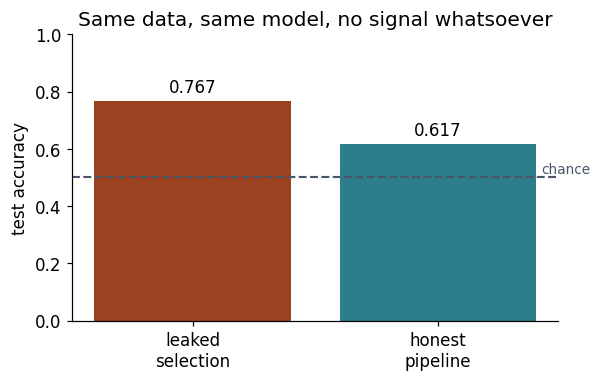

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
bars = ax.bar(["leaked\nselection", "honest\npipeline"], [leaky_acc, honest_acc],
              color=["#9C4221", "#2E7D8A"])
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.axhline(0.5, ls="--", lw=1.4, color="#4A5568")
ax.text(1.42, 0.515, "chance", fontsize=9, color="#4A5568")
ax.set_ylim(0, 1.0)
ax.set_ylabel("test accuracy")
ax.set_title("Same data, same model, no signal whatsoever")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "leakage.png", dpi=150, bbox_inches="tight")
plt.show()

**Why does it work?** Nothing in the data changed, so the answer has to be in what
the selector did.

Start with the shape of the noise. Every one of the 5000 columns has a true
correlation of zero with the label — but a *sample* correlation measured on only 200
rows does not come out at zero. It comes out somewhere within roughly
$1/\sqrt{m} = 0.07$ of it, and the 5000 of them together form a bell curve centred on
zero. Draw 5000 numbers from that and a few will land a long way out, purely by luck.

Now the part that does the damage. **`SelectKBest` is a ranking, not a test.** It never
asks "is this column carrying signal?" — a question it could answer *no* to. It asks
"which are the best 20?", sorts all 5000 by strength of association, and returns the
top of the list. It has no way to return nothing: hand it pure noise and it still hands
back exactly 20 columns.

When the true signal is zero everywhere, sorting by strength is sorting by luck, and
"the top 20 out of 5000" is the definition of the tail. So the selector does not find
the extremes by accident — **selecting the extremes is precisely what it was asked to
do.** The next cell measures the distribution and marks the twenty it kept.

And that is where the test set leaks in. Those correlations were computed over all 200
rows, including the 60 that were about to be held out, so the surviving columns are the
ones that look good *on the test rows too*. The model then rediscovers on the test set
the same accident the selector had already gone looking for.

Note what is **not** at fault. `SelectKBest` is a perfectly good tool, and section 3
uses the identical call correctly by putting it inside the pipeline. Nothing is wrong
with the selector; what is wrong is the line it was called on.


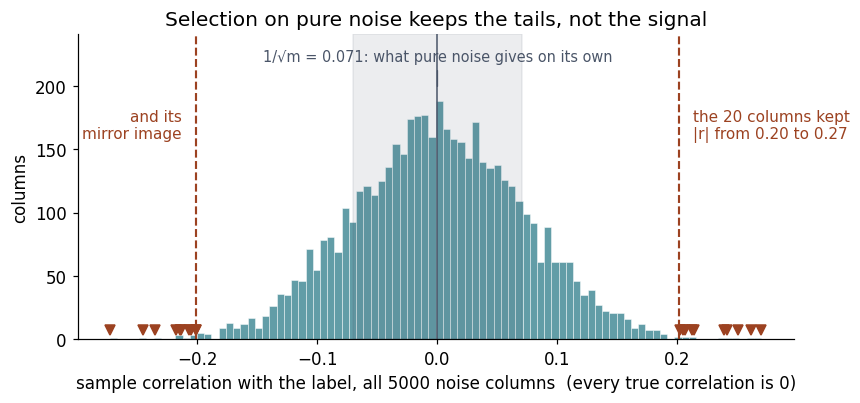

kept |r| between 0.201 and 0.273, against a noise spread of 0.071
the columns kept are exactly the 20 largest |r|: True
they sit 2.8 to 3.9 standard deviations from zero
largest of 5000 draws, predicted by sd*sqrt(2*ln n): 0.292


In [6]:
# The sample correlation of every column with the label, computed directly.
Xc = X_noise - X_noise.mean(axis=0)
yc = y_noise - y_noise.mean()
r = (Xc * yc[:, None]).sum(axis=0) / np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())

kept = selector.get_support(indices=True)     # the 20 columns the leak kept
spread = 1 / np.sqrt(n_samples)
cut = np.abs(r[kept]).min()

fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.hist(r, bins=90, color="#2E7D8A", alpha=0.75, edgecolor="white", linewidth=0.4)
top = ax.get_ylim()[1]
ax.set_ylim(0, top * 1.22)          # headroom, so no label sits on the bars

ax.axvspan(-spread, spread, color="#4A5568", alpha=0.10)
ax.annotate(f"1/\u221am = {spread:.3f}: what pure noise gives on its own",
            xy=(0, top), xytext=(0, top * 1.13), color="#4A5568", fontsize=9.5,
            ha="center", va="center",
            arrowprops=dict(arrowstyle="-", color="#4A5568", lw=0.9))

for edge in (-cut, cut):
    ax.axvline(edge, color="#9C4221", ls="--", lw=1.4)
ax.plot(r[kept], np.full(len(kept), top * 0.035), "v", color="#9C4221", markersize=7)
ax.text(cut + 0.012, top * 0.92,
        f"the {len(kept)} columns kept\n|r| from {cut:.2f} to {np.abs(r[kept]).max():.2f}",
        color="#9C4221", fontsize=10, ha="left", va="top")
ax.text(-cut - 0.012, top * 0.92, "and its\nmirror image",
        color="#9C4221", fontsize=10, ha="right", va="top")

ax.axvline(0.0, color="#4A5568", lw=1.0)
ax.set_xlabel("sample correlation with the label, all 5000 noise columns  "
              "(every true correlation is 0)")
ax.set_ylabel("columns")
ax.set_title("Selection on pure noise keeps the tails, not the signal")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "selection_tail.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"kept |r| between {cut:.3f} and {np.abs(r[kept]).max():.3f}, "
      f"against a noise spread of {spread:.3f}")

# The mechanical claim, checked rather than asserted: the selector's choice is
# exactly "the 20 largest", which on signal-free data means "the 20 luckiest".
top20 = set(np.argsort(-np.abs(r))[:len(kept)])
print(f"the columns kept are exactly the 20 largest |r|: {set(kept) == top20}")
print(f"they sit {cut / r.std():.1f} to {np.abs(r[kept]).max() / r.std():.1f} "
      f"standard deviations from zero")
print(f"largest of 5000 draws, predicted by sd*sqrt(2*ln n): "
      f"{r.std() * np.sqrt(2 * np.log(n_features)):.3f}")

The selection did not find signal — there is none. It found the tails of a
distribution centred on zero, **and it read those tails off all 200 rows**, including
the 60 that were about to become the test set. That is the whole mechanism: the test
information did not enter through the rows, it entered through the choice of columns.

The leaked version invents a result out of nothing. Nobody wrote a bug: every line ran
exactly as intended, and the number it produced is meaningless.

**The rule:** every step that learns anything from the data — scaling, imputation,
encoding, feature selection, tuning — must be fitted inside the training fold. That
is what pipelines are for, and why the previous notebook used one.

### 2.1 How far does this go?

The number above is one draw from one configuration. Two questions decide how
seriously to take it: does the illusion get stronger with **more columns**, and
does it get stronger with **fewer rows**? Both are guesses until measured, so we
measure them — 100 repetitions per setting, because at 40 the effect of the
columns cannot be told from noise.

The cell below takes about half a minute.

In [7]:
def leaked_accuracy(n_samples, n_features, k=20, reps=100, seed0=1000):
    """Repeat the wrong pipeline above and average the test accuracy it reports."""
    accuracies = []
    for r in range(reps):
        rng = np.random.default_rng(seed0 + r)
        X = rng.normal(size=(n_samples, n_features))
        y = rng.integers(0, 2, size=n_samples)
        X_sel = SelectKBest(f_classif, k=k).fit_transform(X, y)   # the leak
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sel, y, test_size=0.3, random_state=RANDOM_STATE)
        model = LogisticRegression(max_iter=5000).fit(X_tr, y_tr)
        accuracies.append((model.predict(X_te) == y_te).mean())
    accuracies = np.array(accuracies)
    return accuracies.mean(), accuracies.std(ddof=1) / np.sqrt(reps)


rows = [50, 100, 200, 400]          # examples, at 5000 columns
cols = [2500, 5000, 10000, 20000]   # columns, at 200 examples

by_rows = [leaked_accuracy(m, 5000) for m in rows]
by_cols = [leaked_accuracy(200, n) for n in cols]

print("fewer rows, 5000 columns fixed")
for m, (acc, sem) in zip(rows, by_rows):
    print(f"  m = {m:>4}   accuracy {acc:.3f} +/- {sem:.3f}")
print("\nmore columns, 200 rows fixed")
for n, (acc, sem) in zip(cols, by_cols):
    print(f"  n = {n:>6}  accuracy {acc:.3f} +/- {sem:.3f}")

fewer rows, 5000 columns fixed
  m =   50   accuracy 0.955 +/- 0.006
  m =  100   accuracy 0.874 +/- 0.005
  m =  200   accuracy 0.799 +/- 0.005
  m =  400   accuracy 0.731 +/- 0.004

more columns, 200 rows fixed
  n =   2500  accuracy 0.776 +/- 0.005
  n =   5000  accuracy 0.799 +/- 0.005
  n =  10000  accuracy 0.813 +/- 0.005
  n =  20000  accuracy 0.830 +/- 0.004


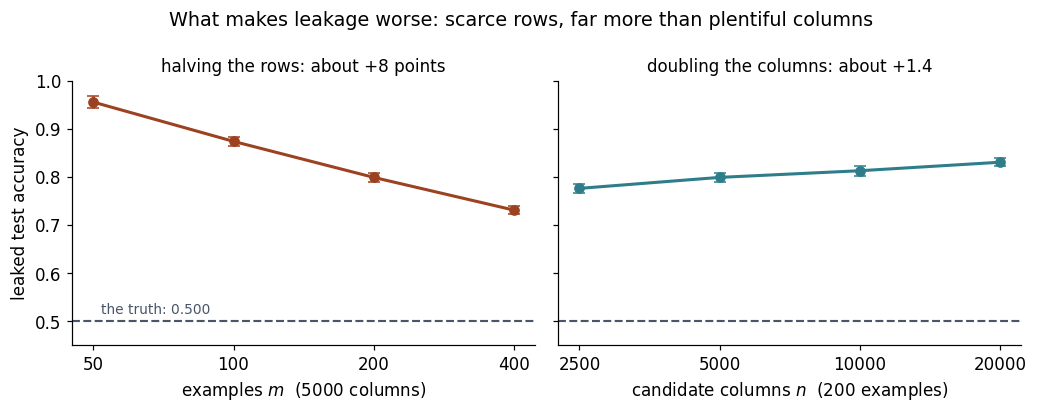

In [8]:
fig, (ax_m, ax_p) = plt.subplots(1, 2, figsize=(9.6, 3.8), sharey=True)

for ax, xs, ys, xlabel, title, colour in [
    (ax_m, rows, by_rows, "examples $m$  (5000 columns)",
     "halving the rows: about +8 points", "#9C4221"),
    (ax_p, cols, by_cols, "candidate columns $n$  (200 examples)",
     "doubling the columns: about +1.4", "#2E7D8A"),
]:
    means = [a for a, _ in ys]
    errs = [1.96 * s for _, s in ys]
    ax.errorbar(xs, means, yerr=errs, marker="o", capsize=4, color=colour, lw=2)
    ax.axhline(0.5, ls="--", lw=1.4, color="#4A5568")
    ax.set_xscale("log", base=2)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(v) for v in xs])
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

ax_m.set_ylabel("leaked test accuracy")
ax_m.set_ylim(0.45, 1.0)
ax_m.text(52, 0.515, "the truth: 0.500", fontsize=9, color="#4A5568")
fig.suptitle("What makes leakage worse: scarce rows, far more than plentiful columns",
             fontsize=12.5)
fig.tight_layout()
fig.savefig(FIGURES / "leakage_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

Both curves rise, and **the two effects are not the same size**. Doubling the
columns buys a little over one point; halving the rows buys about eight. Five
times as much, from the cheaper change.

The reason is in how each side scales. A sample correlation of pure noise has
spread $1/\sqrt{m}$, so halving the rows multiplies it by $1.41$. The largest of
$n$ such draws grows like $\sqrt{2\ln n}$, so doubling the columns multiplies it
by only $1.04$. More columns give the selector more lottery tickets; fewer rows
make every ticket pay better.

**The practical reading:** leakage is at its most dangerous exactly where data is
scarce — which is also where it is hardest to detect, because there is no room to
hold out enough of it to notice.

## 3. Imbalance: 99% accuracy that detects nothing

A screening problem where 1% of cases are positive. A model that answers "negative"
every time scores 99%.

In [9]:
X_imb, y_imb = make_classification(
    n_samples=5000, n_features=20, n_informative=6,
    weights=[0.99, 0.01], flip_y=0.01, random_state=RANDOM_STATE,
)
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=RANDOM_STATE, stratify=y_imb
)
print(f"positives in the test set: {yi_test.sum()} out of {len(yi_test)} ({yi_test.mean():.1%})")

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
model.fit(Xi_train, yi_train)
y_pred = model.predict(Xi_test)

always_negative = np.zeros_like(yi_test)
print(f"\naccuracy, always answering 'negative': {accuracy_score(yi_test, always_negative):.3f}")
print(f"accuracy, trained model:               {accuracy_score(yi_test, y_pred):.3f}")
print(f"\nrecall on positives, always 'negative': {recall_score(yi_test, always_negative, zero_division=0):.3f}")
print(f"recall on positives, trained model:     {recall_score(yi_test, y_pred):.3f}")

positives in the test set: 21 out of 1500 (1.4%)

accuracy, always answering 'negative': 0.986
accuracy, trained model:               0.987

recall on positives, always 'negative': 0.000
recall on positives, trained model:     0.048


In [10]:
cm = confusion_matrix(yi_test, y_pred)
missed = cm[1, 0]
print(f"positives the model missed: {missed} of {yi_test.sum()}")
print("\nconfusion matrix:")
print(pd.DataFrame(cm, index=["true negative", "true positive"],
                   columns=["predicted neg", "predicted pos"]))

positives the model missed: 20 of 21

confusion matrix:
               predicted neg  predicted pos
true negative           1479              0
true positive             20              1


The trained model beats the trivial one, but read the recall, not the accuracy. On a
problem where the positives are the entire reason the system exists, accuracy is
dominated by the class nobody is looking for.

**The rule:** on imbalanced data, accuracy is close to meaningless. Choose a metric
that looks at the class you actually care about — and always compare against the
trivial baseline, which is unbeatable on accuracy and useless in practice.

## 4. A shortcut feature: the model learns the wrong thing

Real datasets often contain a column that is a consequence of the label rather than a
cause — something recorded *because* the outcome was already known.

We take the tumour data and add a column called `biopsy_scheduled`, which is 1 for
almost every malignant case. In a hospital extract this is exactly the kind of field
that arrives without comment.

In [11]:
data = load_breast_cancer(as_frame=True)
Xs, ys = data.data.copy(), data.target

# 0 = malignant. Biopsies are scheduled once malignancy is already suspected, so this
# column encodes the answer - it is a consequence of the diagnosis, not a predictor.
rng = np.random.default_rng(RANDOM_STATE)
Xs["biopsy_scheduled"] = np.where(ys == 0, 1, 0)
flip = rng.random(len(ys)) < 0.03            # a little noise, so it is not a perfect copy
Xs.loc[flip, "biopsy_scheduled"] = 1 - Xs.loc[flip, "biopsy_scheduled"]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    Xs, ys, test_size=0.25, random_state=RANDOM_STATE, stratify=ys
)
shortcut = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
shortcut.fit(Xt_train, yt_train)
print(f"accuracy with the shortcut column: {shortcut.score(Xt_test, yt_test):.3f}")

coefs = pd.Series(shortcut[-1].coef_[0], index=Xs.columns).abs().sort_values(ascending=False)
print("\nfeatures the model leaned on hardest:")
print(coefs.head(5).round(3))

accuracy with the shortcut column: 0.986

features the model leaned on hardest:
biopsy_scheduled        2.131
mean compactness        0.780
worst concave points    0.741
radius error            0.720
worst symmetry          0.697
dtype: float64


Accuracy goes up and the model is now worse than useless, because the column it relies
on is only available *after* the diagnosis it is supposed to predict. Deployed on a new
patient, that field is empty — and the model has learnt to lean on it instead of on the
measurements.

This is not a subtle statistical issue. It is a question about the data-generating
process: *at the moment a prediction is needed, does this value exist yet?* No metric
will ask that for you.

**The rule:** for every feature, know when it is recorded and why. A cross-validated
score cannot detect a column that leaks the future.

## 5. A single split is a noisy measurement

The last one is quieter and nearly universal. Report the accuracy from one train/test
split and you are reporting one draw from a distribution — while implying it is a
property of the model.

In [12]:
X_small, y_small = data.data[:200], data.target[:200]

scores = []
for seed in range(30):
    Xa, Xb, ya, yb = train_test_split(X_small, y_small, test_size=0.3, random_state=seed, stratify=y_small)
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    m.fit(Xa, ya)
    scores.append(m.score(Xb, yb))

scores = np.array(scores)
print(f"lowest  : {scores.min():.3f}")
print(f"highest : {scores.max():.3f}")
print(f"mean    : {scores.mean():.3f}  (std {scores.std():.3f})")
print(f"\nspread across nothing but the choice of split: {scores.max() - scores.min():.3f}")

lowest  : 0.917
highest : 1.000
mean    : 0.963  (std 0.020)

spread across nothing but the choice of split: 0.083


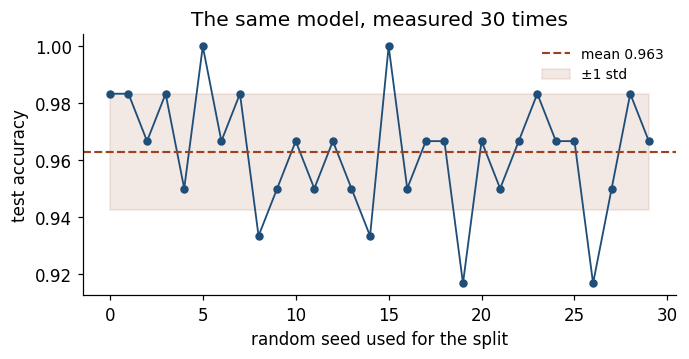

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(range(len(scores)), scores, "o-", color="#1F4E79", ms=4.5, lw=1.2)
ax.axhline(scores.mean(), ls="--", lw=1.4, color="#9C4221",
           label=f"mean {scores.mean():.3f}")
ax.fill_between(range(len(scores)), scores.mean() - scores.std(), scores.mean() + scores.std(),
                color="#9C4221", alpha=.12, label="±1 std")
ax.set_xlabel("random seed used for the split")
ax.set_ylabel("test accuracy")
ax.set_title("The same model, measured 30 times")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "split_variance.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
cv = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    X_small, y_small, cv=5,
)
print(f"5-fold cross-validation: {cv.mean():.3f} ± {cv.std():.3f}")
print(f"individual folds: {np.round(cv, 3)}")

5-fold cross-validation: 0.960 ± 0.030
individual folds: [0.975 0.925 0.975 0.925 1.   ]


Pick your favourite seed and you can report anything within that range. Nobody reading
a single number can tell which one you got.

Cross-validation replaces the single draw with an average over several, and — more
usefully — reports the spread alongside it. A result quoted without any indication of
its variability is an incomplete result. Lesson 5 makes this the centre of the course.

> **Try this:** section 2.1 measured what happens with more columns and with
> fewer rows. Now predict, before running it: what happens to the leaked accuracy
> if you keep 200 rows and 5000 columns but raise `k` from 20 to 200? Is the
> illusion stronger or weaker, and why?

## 6. What these four have in common

| Failure | What it looks like | What actually happened |
|---|---|---|
| Leakage | Excellent test score | The test set influenced a decision |
| Imbalance | 99% accuracy | The metric ignores the class that matters |
| Shortcut feature | Score improves when a column is added | The column encodes the answer and will not exist at prediction time |
| Single split | One clean number | One draw from a distribution, reported as a property |

None of these is a coding error. All four run exactly as written and return a number
that a reviewer, a supervisor or a customer would accept.

They are caught by asking questions about the data and the process, not by reading the
metric: **where did this number come from, what does it leave out, and would it still
hold on data I have never touched?** That question is the discipline this whole course
is built to teach.

## Summary

- Fit every learning step - scaling, selection, tuning - inside the training fold. A
  pipeline enforces this; doing it by hand eventually will not.
- On imbalanced problems, accuracy measures the class you are not interested in.
- Know when each feature is recorded. A column that exists only after the outcome
  cannot be a predictor, and no metric will flag it.
- One split is one measurement. Report variability, or report nothing.
- Treat an unexpectedly good result as a reason to investigate, not to celebrate.